# FinSight — Income Regressor Analysis (Savings Forecast)

**What this notebook tests**

You noticed that discretionary spending (Shopping, eating out, Uber, non-essential
Education) tracks your income cycle — part-time during school, full-time in summer —
while essentials (Rent, Groceries) don't move with income the same way. The question:
does feeding Prophet your monthly **Income** as a regressor actually improve the
**Savings** forecast, or does it just narrow the confidence interval without a real
accuracy gain?

We're testing on **Savings** (not Shopping/other discretionary categories) because
this is your main chequing account and Income + Savings (auto-save transfers out) are
the only two things that flow through it consistently — you use a credit card for most
discretionary spend, so that data wouldn't live here.

**Design decisions already locked in for the real `/forecast` endpoint (not this
notebook specifically, but this notebook follows them so the test is representative):**
- Monthly bucketing
- Forecast horizon: next 1 month
- Minimum 3 months of history required to fit at all
- Gaps (months with zero transactions in a category) filled as explicit $0, not skipped
- The current, still-in-progress month is always excluded from training data
- Yearly/weekly/daily seasonality explicitly OFF (not "auto") — ~19 months isn't enough
  to reliably separate a real annual pattern from noise (need ~2+ full cycles to even
  identify seasonality, let alone estimate it well)

**How we're testing the regressor honestly (not just eyeballing in-sample fit)**

If we fit both models on *all* the data and just look at how well they explain the past,
the regressor version will basically always look better — that's not a fair test, it's
guaranteed by giving the model more information about the exact period it's being scored
on. Instead we hold out the last 3 months, train both models on everything before that,
and see which one predicts those unseen months more accurately. That's the real test.

**Caveat going in:** 3 held-out months is a very small test set. Whatever we see here is
a *directional signal*, not a statistically solid conclusion. Treat it as "does this look
promising enough to build for real," not "this proves it works."


In [17]:
# Run once if you don't already have these installed:
# pip install supabase prophet pandas matplotlib numpy


In [18]:
import pandas as pd
import numpy as np
from supabase import create_client
from prophet import Prophet
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from pathlib import Path

## 1. Credentials

- `SUPABASE_URL` / `SUPABASE_KEY`: Supabase dashboard → Project Settings → API
  (use the `anon` public key — same one your FastAPI backend uses)
- `USER_ID`: your user id from the `auth.users` table, or decode it from a JWT
- `CHEQUING_ACCOUNT_ID`: the `id` of your main chequing account from the `accounts` table


In [19]:
ENV_PATH = Path("../backend/.env")  # adjust if needed
load_dotenv(ENV_PATH)

SUPABASE_URL = os.environ["SUPABASE_URL"]
SUPABASE_KEY = os.environ["SUPABASE_KEY"]
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
USER_ID = "328c7f2e-9d3d-46c2-a9cf-4c95267c4d01"
CHEQUING_ACCOUNT_ID = "196d0050-38c1-4d5c-b6a6-999183ff0c4e"


## 2. Pull all transactions for this account

Paginated in case you're above Supabase's default 1000-row response cap
(you're at ~770 total across all accounts, so this is precautionary, not
strictly necessary yet).


In [20]:
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

def fetch_all_transactions(user_id, account_id, page_size=1000):
    all_rows = []
    start = 0
    while True:
        resp = (
            supabase.table("transactions")
            .select("*")
            .eq("user_id", user_id)
            .eq("account_id", account_id)
            .order("date")
            .range(start, start + page_size - 1)
            .execute()
        )
        rows = resp.data
        all_rows.extend(rows)
        if len(rows) < page_size:
            break
        start += page_size
    return all_rows

raw_rows = fetch_all_transactions(USER_ID, CHEQUING_ACCOUNT_ID)
print(f"Fetched {len(raw_rows)} transactions")


Fetched 773 transactions


## 3. Load into a DataFrame

**Schema reminder** (matches `TransactionResponse`): `id`, `user_id`, `batch_id`,
`account_id`, `date`, `description`, `amount` (negative = debit/money out, positive =
credit/money in), `category`, `account_type`, `is_anomaly`, `anomaly_score`, `created_at`.


In [21]:
df = pd.DataFrame(raw_rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df[["date", "description", "amount", "category"]].head(10)


,date,description,amount,category
0,2025-01-02,E-TRANSFER SENT MR MARK 8GNST6,-650.00,Rent/Mortgage
1,2025-01-02,ONLINE BANKING TRANSFER - 4061,650.00,Transfer
2,2025-01-03,PAYROLL DEPOSIT E-CHILDREN LTD,966.92,Income
3,2025-01-03,ONLINE BANKING TRANSFER - 0473,-52.72,Transfer
4,2025-01-06,ONLINE BANKING TRANSFER - 4573,-27.00,Transfer
5,2025-01-06,E-TRANSFER SENT JV TIFFIN BWUCE5,-60.00,Transfer
6,2025-01-06,E-TRANSFER - AUTODEPOSIT JAY M PATEL C1AHTETS5TAG,2600.00,Transfer
7,2025-01-07,TO FIND & SAVE,-75.00,Savings
8,2025-01-07,ONLINE BANKING PAYMENT - 9573 SAIT - TUITION,-2599.00,Education
9,2025-01-08,TO FIND & SAVE,-75.00,Savings


## 4. Build monthly Income / Savings / Rent series

- `Income` amounts should already be positive (credits).
- `Savings` and `Rent/Mortgage` are debits (negative) — we take `.abs()` to get the
  outflow as a positive magnitude, since that's the natural way to think about "how much
  went to savings" or "how much rent cost."

**Sanity check before trusting this:** print `monthly["income"]` below and confirm it's
positive. If your data has income coming through as negative for some reason, flip the
sign here before continuing — everything downstream assumes income is positive.


In [22]:
df["month"] = df["date"].dt.to_period("M")

monthly_income = (
    df[df["category"] == "Income"]
    .groupby("month")["amount"]
    .sum()
    .rename("income")
)

monthly_savings = (
    df[df["category"] == "Savings"]
    .groupby("month")["amount"]
    .sum()
    .abs()
    .rename("savings")
)

monthly_rent = (
    df[df["category"] == "Rent/Mortgage"]
    .groupby("month")["amount"]
    .sum()
    .abs()
    .rename("rent")
)

monthly = pd.concat([monthly_income, monthly_savings, monthly_rent], axis=1).fillna(0.0)
monthly = monthly.sort_index()
monthly


,income,savings,rent
month,,,
2025-01,2300.46,425.0,650.0
2025-02,1361.46,499.0,1300.0
2025-03,1368.19,0.0,0.0
2025-04,2244.30,759.0,650.0
2025-05,1983.44,596.0,650.0
2025-06,2263.04,661.0,650.0
2025-07,2318.01,375.0,650.0
2025-08,2957.27,712.0,650.0
2025-09,2480.20,648.0,650.0


## 5. Drop the current, still-in-progress month

Matches the design decision for the real endpoint — a partial month looks like a fake
drop in spending/savings and would distort the trend right where it matters most.


In [23]:
current_month = pd.Timestamp.now().to_period("M")
monthly = monthly[monthly.index < current_month]
print(f"Excluded current in-progress month ({current_month}). Remaining months: {len(monthly)}")

monthly = monthly.reset_index()
monthly["ds"] = monthly["month"].dt.to_timestamp()  # Prophet wants a real timestamp, first-of-month
monthly


Excluded current in-progress month (2026-07). Remaining months: 18


,month,income,savings,rent,ds
0,2025-01,2300.46,425.0,650.0,2025-01-01
1,2025-02,1361.46,499.0,1300.0,2025-02-01
2,2025-03,1368.19,0.0,0.0,2025-03-01
3,2025-04,2244.30,759.0,650.0,2025-04-01
4,2025-05,1983.44,596.0,650.0,2025-05-01
5,2025-06,2263.04,661.0,650.0,2025-06-01
6,2025-07,2318.01,375.0,650.0,2025-07-01
7,2025-08,2957.27,712.0,650.0,2025-08-01
8,2025-09,2480.20,648.0,650.0,2025-09-01
9,2025-10,1716.88,432.0,650.0,2025-10-01


## 6. Train / holdout split

Hold out the last 3 months as a fair accuracy test — the models never see these during
training, so predicting them is a genuine test, not a look-back.


In [24]:
HOLDOUT_MONTHS = 3

train = monthly.iloc[:-HOLDOUT_MONTHS].copy()
test = monthly.iloc[-HOLDOUT_MONTHS:].copy()

print(f"Training on {len(train)} months, testing on the last {len(test)}")
print("Held-out months:", test["ds"].dt.strftime("%Y-%m").tolist())


Training on 15 months, testing on the last 3
Held-out months: ['2026-04', '2026-05', '2026-06']


## 7. Baseline model — Savings, no income regressor

**Prophet terminology, as it comes up:**
- `ds` — the date column Prophet requires (short for "datestamp")
- `y` — the value being predicted (Prophet requires this exact column name)
- `yhat` — the model's point prediction ("y hat," the predicted value)
- `yhat_lower` / `yhat_upper` — the uncertainty interval around that prediction
  (80% interval by default). Narrower = the model is more confident; wider = it's
  telling you honestly that it doesn't have a strong basis to narrow it down.
- `add_regressor()` — tells Prophet "here's an extra input signal, learn a coefficient
  for how it relates to y," on top of trend/seasonality.


In [25]:
def make_prophet():
    # Seasonality explicitly OFF rather than left on 'auto' — see notebook intro
    # for why ~19 months isn't enough to trust yearly seasonality, and monthly
    # bucketing removes any weekly/daily pattern to find anyway.
    return Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
    )

baseline_train = train[["ds"]].copy()
baseline_train["y"] = train["savings"]

baseline_model = make_prophet()
baseline_model.fit(baseline_train)

baseline_forecast = baseline_model.predict(test[["ds"]].copy())
baseline_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]


17:42:52 - cmdstanpy - INFO - Chain [1] start processing
17:42:52 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
0,2026-04-01,284.500735,33.466913,535.532014
1,2026-05-01,267.681806,6.919427,525.285911
2,2026-06-01,250.302245,-2.852361,514.826005


In [26]:
baseline_compare = baseline_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
baseline_compare["actual"] = test["savings"].values
baseline_compare["abs_error"] = (baseline_compare["actual"] - baseline_compare["yhat"]).abs()
baseline_compare["interval_width"] = baseline_compare["yhat_upper"] - baseline_compare["yhat_lower"]

baseline_mae = baseline_compare["abs_error"].mean()
print(f"Baseline (no income regressor) MAE: ${baseline_mae:.2f}")
baseline_compare


Baseline (no income regressor) MAE: $320.51


,ds,yhat,yhat_lower,yhat_upper,actual,abs_error,interval_width
0,2026-04-01,284.500735,33.466913,535.532014,825.0,540.499265,502.065102
1,2026-05-01,267.681806,6.919427,525.285911,593.0,325.318194,518.366484
2,2026-06-01,250.302245,-2.852361,514.826005,346.0,95.697755,517.678366


## 8. With income as a regressor

For this test we use the **actual, already-known** income for the held-out months as
the regressor input — because right now we're only testing "does income explain past
savings variance," not yet solving the separate, harder problem of needing a *forecasted*
future income value in production (that would mean forecasting Income first, then feeding
that prediction into the Savings model — a real cross-category dependency we haven't
committed to building).


In [27]:
regressor_train = train[["ds", "savings", "income"]].rename(columns={"savings": "y"})

regressor_model = make_prophet()
regressor_model.add_regressor("income")
regressor_model.fit(regressor_train)

regressor_forecast = regressor_model.predict(test[["ds", "income"]].copy())

regressor_compare = regressor_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
regressor_compare["actual"] = test["savings"].values
regressor_compare["abs_error"] = (regressor_compare["actual"] - regressor_compare["yhat"]).abs()
regressor_compare["interval_width"] = regressor_compare["yhat_upper"] - regressor_compare["yhat_lower"]

regressor_mae = regressor_compare["abs_error"].mean()
print(f"With income regressor MAE: ${regressor_mae:.2f}")
regressor_compare


17:42:52 - cmdstanpy - INFO - Chain [1] start processing
17:42:52 - cmdstanpy - INFO - Chain [1] done processing


With income regressor MAE: $214.71


,ds,yhat,yhat_lower,yhat_upper,actual,abs_error,interval_width
0,2026-04-01,436.754909,231.751499,643.096107,825.0,388.245091,411.344609
1,2026-05-01,352.317303,155.214513,542.244361,593.0,240.682697,387.029847
2,2026-06-01,330.792640,140.696331,508.600984,346.0,15.207360,367.904653


## 9. Side-by-side comparison

**How to read this:**
- Lower `MAE` (mean absolute error, in dollars) = more accurate predictions on the
  months we held out.
- Smaller `interval_width` = the model is more confident. Only trust a smaller interval
  if the MAE is *also* better — a smaller interval with worse or equal MAE means the
  model got more confident without actually getting more accurate, which is the false-
  precision failure mode we were worried about going in.
- With only 3 held-out months, don't over-read a small MAE difference either way —
  look for a large, obvious gap, not a marginal one.


In [28]:
comparison = pd.DataFrame({
    "month": test["ds"].dt.strftime("%Y-%m").values,
    "actual_savings": test["savings"].values,
    "baseline_yhat": baseline_compare["yhat"].values,
    "baseline_interval_width": baseline_compare["interval_width"].values,
    "regressor_yhat": regressor_compare["yhat"].values,
    "regressor_interval_width": regressor_compare["interval_width"].values,
})

print(f"Baseline MAE:        ${baseline_mae:.2f}")
print(f"With-regressor MAE:  ${regressor_mae:.2f}")
comparison


Baseline MAE:        $320.51
With-regressor MAE:  $214.71


,month,actual_savings,baseline_yhat,baseline_interval_width,regressor_yhat,regressor_interval_width
0,2026-04,825.0,284.500735,502.065102,436.754909,411.344609
1,2026-05,593.0,267.681806,518.366484,352.317303,387.029847
2,2026-06,346.0,250.302245,517.678366,330.792640,367.904653


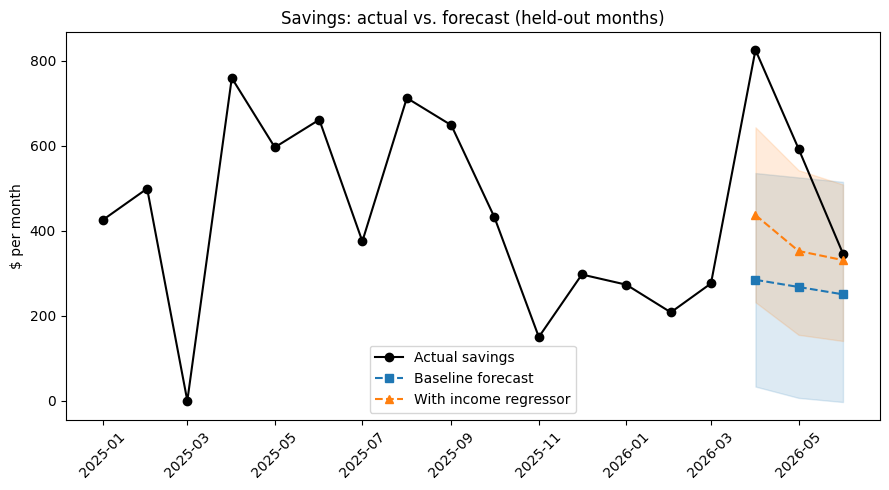

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly["ds"], monthly["savings"], "o-", label="Actual savings", color="black")
ax.plot(test["ds"], baseline_compare["yhat"], "s--", label="Baseline forecast", color="tab:blue")
ax.fill_between(test["ds"], baseline_compare["yhat_lower"], baseline_compare["yhat_upper"],
                 alpha=0.15, color="tab:blue")
ax.plot(test["ds"], regressor_compare["yhat"], "^--", label="With income regressor", color="tab:orange")
ax.fill_between(test["ds"], regressor_compare["yhat_lower"], regressor_compare["yhat_upper"],
                 alpha=0.15, color="tab:orange")
ax.set_title("Savings: actual vs. forecast (held-out months)")
ax.set_ylabel("$ per month")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 10. Control check — Rent/Mortgage

You said Rent shouldn't move with income the way Savings/discretionary spend does. If
adding the income regressor also "improves" the Rent forecast by a lot, that's a red
flag — it would mean the model is fitting something spurious (e.g. both series happen to
trend together over these ~19 months for unrelated reasons) rather than a real
income → spending relationship. We'd expect these two numbers to be close.


In [30]:
baseline_rent_train = train[["ds"]].copy()
baseline_rent_train["y"] = train["rent"]

baseline_rent_model = make_prophet()
baseline_rent_model.fit(baseline_rent_train)
baseline_rent_forecast = baseline_rent_model.predict(test[["ds"]].copy())

regressor_rent_train = train[["ds", "rent", "income"]].rename(columns={"rent": "y"})
regressor_rent_model = make_prophet()
regressor_rent_model.add_regressor("income")
regressor_rent_model.fit(regressor_rent_train)
regressor_rent_forecast = regressor_rent_model.predict(test[["ds", "income"]].copy())

rent_baseline_mae = np.abs(test["rent"].values - baseline_rent_forecast["yhat"].values).mean()
rent_regressor_mae = np.abs(test["rent"].values - regressor_rent_forecast["yhat"].values).mean()

print(f"Rent/Mortgage baseline MAE:       ${rent_baseline_mae:.2f}")
print(f"Rent/Mortgage with income regr.:  ${rent_regressor_mae:.2f}")
print("Expectation: these should be close. A big drop on the regressor side here would be suspicious, not good news.")


17:42:53 - cmdstanpy - INFO - Chain [1] start processing
17:42:53 - cmdstanpy - INFO - Chain [1] done processing
17:42:53 - cmdstanpy - INFO - Chain [1] start processing
17:42:53 - cmdstanpy - INFO - Chain [1] done processing


Rent/Mortgage baseline MAE:       $426.46
Rent/Mortgage with income regr.:  $426.35
Expectation: these should be close. A big drop on the regressor side here would be suspicious, not good news.


## What to do with the results

- **Savings MAE clearly better with the regressor, and Rent MAE roughly unchanged** →
  real signal, worth building the regressor into `/forecast` for Savings (and we'd still
  need to solve the "future income value" dependency before it's production-ready).
- **Savings MAE about the same, but interval narrower** → the false-precision pattern we
  were worried about — don't use it.
- **Rent MAE also drops a lot with the regressor** → don't trust the Savings result
  either; something other than a real income relationship is being picked up.
- **Any result** — remember this is 3 held-out months from one user's data. Treat this as
  "worth building" vs. "not worth building," not as a validated production accuracy
  number.
